In [1]:
from functools import partial

import matplotlib.pyplot as plt

from superfv import plot_1d_slice
from superfv.initial_conditions import sedov
from teyssier.sedov import sedovana
from superfv.tools.run_helper import run_multiple_simulations

In [2]:
gamma = 1.4
N = 100
T = 0.8

init_params = dict(
    ic=partial(sedov, P0=1e-5, h=1 / N, gamma=gamma),
    gamma=gamma,
    bcx=("reflective", "free"),
    nx=N,
    PAD={"rho": (0, None), "P": (0, None)},
)
run_parmas = dict(T=T)

In [3]:
musclhancock = dict(p=1, MUSCL=True, MUSCL_limiter="moncen")
apriori = dict(ZS=True, lazy_primitives="adaptive")
aposteriori = dict(MOOD=True, lazy_primitives="full", MUSCL_limiter="moncen")
aposteriori_1rev = dict(cascade="muscl", max_MOOD_iters=1, **aposteriori)
aposteriori_2revs = dict(cascade="muscl0", max_MOOD_iters=2, **aposteriori)
aposteriori_3revs = dict(cascade="muscl0", max_MOOD_iters=3, **aposteriori)

configs = {
    "MUSCL-Hancock": musclhancock,
    "ZS3": dict(p=3, **apriori),
    "ZS7": dict(p=7, **apriori),
    "MM3/1rev/no_NAD": dict(p=3, NAD=False, SED=False, **aposteriori_1rev),
    "MM7/1rev/no_NAD": dict(p=7, NAD=False, SED=False, **aposteriori_1rev),
    "MM3/1rev/rtol_1e0": dict(p=3, NAD_rtol=1e0, **aposteriori_1rev),
    "MM7/1rev/rtol_1e0": dict(p=7, NAD_rtol=1e0, **aposteriori_1rev),
    "MM3/1rev/rtol_1e-1": dict(p=3, NAD_rtol=1e-1, **aposteriori_1rev),
    "MM7/1rev/rtol_1e-1": dict(p=7, NAD_rtol=1e-1, **aposteriori_1rev),
    "MM3/1rev/rtol_1e-2": dict(p=3, NAD_rtol=1e-2, **aposteriori_1rev),
    "MM7/1rev/rtol_1e-2": dict(p=7, NAD_rtol=1e-2, **aposteriori_1rev),
    "MM3/1rev/rtol_1e-3": dict(p=3, NAD_rtol=1e-3, **aposteriori_1rev),
    "MM7/1rev/rtol_1e-3": dict(p=7, NAD_rtol=1e-3, **aposteriori_1rev),
    "MM3/1rev/rtol_1e-5": dict(p=3, NAD_rtol=1e-5, **aposteriori_1rev),
    "MM7/1rev/rtol_1e-5": dict(p=7, NAD_rtol=1e-5, **aposteriori_1rev),
    "MM3/1rev/rtol_0": dict(p=3, NAD_rtol=0, **aposteriori_1rev),
    "MM7/1rev/rtol_0": dict(p=7, NAD_rtol=0, **aposteriori_1rev),
}

In [4]:
sims = {}


def postprocess(name, sim):
    sims[name] = sim


run_multiple_simulations(
    {
        name: (
            init_params | config,
            run_parmas,
        )
        for name, config in configs.items()
    },
    "/scratch/gpfs/jp7427/out/sedov-1d/",
    postprocess=postprocess,
)

Successfully read simulation output from "/scratch/gpfs/jp7427/out/sedov-1d/MUSCL-Hancock"
Output exists for MUSCL-Hancock, skipping...
Successfully read simulation output from "/scratch/gpfs/jp7427/out/sedov-1d/ZS3"
Output exists for ZS3, skipping...
Successfully read simulation output from "/scratch/gpfs/jp7427/out/sedov-1d/ZS7"
Output exists for ZS7, skipping...
Successfully read simulation output from "/scratch/gpfs/jp7427/out/sedov-1d/MM3/1rev/no_NAD"
Output exists for MM3/1rev/no_NAD, skipping...
Error exists for MM7/1rev/no_NAD with the following contents:
Computed time-step size smaller than 1e-15.

Skipping...

Successfully read simulation output from "/scratch/gpfs/jp7427/out/sedov-1d/MM3/1rev/rtol_1e0"
Output exists for MM3/1rev/rtol_1e0, skipping...
Successfully read simulation output from "/scratch/gpfs/jp7427/out/sedov-1d/MM7/1rev/rtol_1e0"
Output exists for MM7/1rev/rtol_1e0, skipping...
Successfully read simulation output from "/scratch/gpfs/jp7427/out/sedov-1d/MM3/1rev

In [5]:
# analytical solution for plotting
dim = 1
E0 = 1
rho0 = 1

r, d, u, P = sedovana(gamma, dim)

r *= (E0 / rho0) ** (1.0 / (dim + 2)) * T ** (2 / (dim + 2))
d *= rho0
u *= (E0 / rho0) ** (1.0 / (dim + 2)) * T ** (-dim / (dim + 2))
P *= (E0 / rho0) ** (2.0 / (dim + 2)) * T ** (-2 * dim / (dim + 2)) * rho0

chi0=np.float64(0.97306051566207)


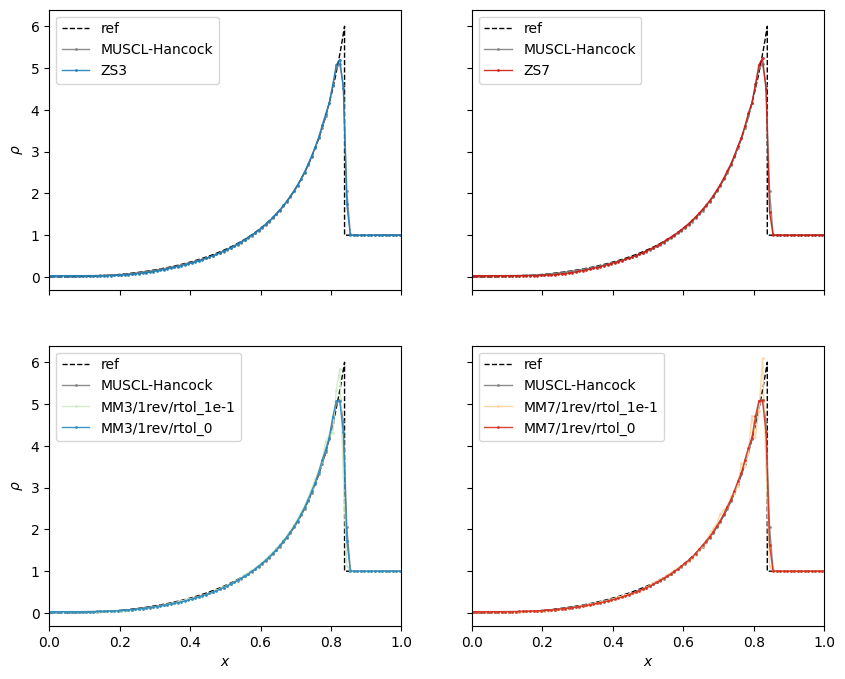

In [6]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10, 8))
axs[1, 0].set_xlabel(r"$x$")
axs[1, 1].set_xlabel(r"$x$")
axs[0, 0].set_ylabel(r"$\rho$")
axs[1, 0].set_ylabel(r"$\rho$")
axs[0, 0].set_xlim(0, 1)

cmap1 = plt.get_cmap("GnBu")
cmap2 = plt.get_cmap("OrRd")


common_style = dict(linewidth=1, markersize=1, mfc="none")


def plot(name, ax, v, style=dict()):
    plot_1d_slice(
        sims[name],
        ax,
        v,
        label=name,
        marker="o",
        alpha=0.9,
        **(common_style | style),
    )


axs[0, 0].plot(r, d, color="k", linestyle="--", label="ref", **common_style)
plot("MUSCL-Hancock", axs[0, 0], "rho", dict(color="grey"))
plot("ZS3", axs[0, 0], "rho", dict(color=cmap1(0.8)))

axs[0, 1].plot(r, d, color="k", linestyle="--", label="ref", **common_style)
plot("MUSCL-Hancock", axs[0, 1], "rho", dict(color="grey"))
plot("ZS7", axs[0, 1], "rho", dict(color=cmap2(0.8)))

axs[1, 0].plot(r, d, color="k", linestyle="--", label="ref", **common_style)
plot("MUSCL-Hancock", axs[1, 0], "rho", dict(color="grey"))
plot("MM3/1rev/rtol_1e-1", axs[1, 0], "rho", dict(color=cmap1(0.25)))
plot("MM3/1rev/rtol_0", axs[1, 0], "rho", dict(color=cmap1(0.75)))

axs[1, 1].plot(r, d, color="k", linestyle="--", label="ref", **common_style)
plot("MUSCL-Hancock", axs[1, 1], "rho", dict(color="grey"))
plot("MM7/1rev/rtol_1e-1", axs[1, 1], "rho", dict(color=cmap2(0.25)))
plot("MM7/1rev/rtol_0", axs[1, 1], "rho", dict(color=cmap2(0.75)))


axs[0, 0].legend()
axs[0, 1].legend()
axs[1, 0].legend()
axs[1, 1].legend()

In [7]:
fig.savefig("sedov-1d.pdf")